## Análisis Exploratorio de Datos (EDA): Distribución de Felinos Salvajes en Sudamérica.

El objetivo de este proyecto es analizar los patrones espaciales y temporales de las especies de la familia Felidae dentro del territorio sudamericano. El dataset original fue extraído de la plataforma global GBIF, filtrando por la familia biológica para integrar tanto a los grandes depredadores (como el yaguareté y el puma) como a los pequeños felinos endémicos del continente.

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') 

RUTA_DATOS = os.path.join('..', 'Datos', 'Felinos_Sudamerica.csv')

# Carga del dataset 
df = pd.read_csv(RUTA_DATOS, sep='\t', low_memory=False)

print("=== PROYECTO: FELINOS SALVAJES DE AMÉRICA DEL SUR ===")
print(f"Volumen inicial del dataset: {df.shape[0]:,} filas y {df.shape[1]} columnas.")



=== PROYECTO: FELINOS SALVAJES DE AMÉRICA DEL SUR ===
Volumen inicial del dataset: 174,051 filas y 50 columnas.


El dataset cuenta con un volumen masivo de 174,051 registros de avistamientos. Este tamaño garantiza una muestra estadísticamente sólida para el entrenamiento de algoritmos.El archivo original provee 50 dimensiones (columnas), de las cuales se ha realizado una selección estratégica de 9 variables críticas orientadas a factores ecológicos, geográficos y temporales, descartando metadatos administrativos de la plataforma GBIF para optimizar el rendimiento del procesamiento.

Inspección de Columnas y Calidad de los Datos

In [5]:
# Variables clave para el análisis de hábitats y machine learning
columnas_estudio = [
    'species', 'decimalLatitude', 'decimalLongitude', 'elevation', 
    'year', 'month', 'countryCode', 'basisOfRecord', 'stateProvince'
]

# Construcción de la tabla de diagnóstico de calidad
diagnostico = pd.DataFrame({
    'Tipo de Dato': df[columnas_estudio].dtypes,
    'Valores Únicos': df[columnas_estudio].nunique(),
    'Datos Faltantes (Cant.)': df[columnas_estudio].isnull().sum(),
    'Datos Faltantes (%)': (df[columnas_estudio].isnull().sum() / len(df)) * 100
})

print("=== DIAGNÓSTICO DE CALIDAD DE VARIABLES SELECCIONADAS ===")
display(diagnostico)



=== DIAGNÓSTICO DE CALIDAD DE VARIABLES SELECCIONADAS ===


,Tipo de Dato,Valores Únicos,Datos Faltantes (Cant.),Datos Faltantes (%)
species,object,29,3637,2.089617
decimalLatitude,float64,122238,7853,4.511896
decimalLongitude,float64,121783,7853,4.511896
elevation,float64,1625,157187,90.310886
year,float64,162,4835,2.777921
month,float64,12,7202,4.137868
countryCode,object,10,0,0.000000
basisOfRecord,object,8,0,0.000000
stateProvince,object,338,129468,74.385094


* Integridad Geográfica: Existe un 4.51% de registros faltantes en las coordenadas (decimalLatitude y decimalLongitude). Como nuestro enfoque incluye clustering espacial, estas filas representan ruido insalvable y serán eliminadas en la limpieza.
* El desafío de la Altitud (elevation): Presenta un crítico 90.31% de datos faltantes. Utilizar esta columna directamente en los modelos introduciría un sesgo severo debido a la masiva imputación requerida. Decisión técnica: Se mantendrá en el EDA para análisis descriptivo, pero se evaluará su exclusión o una reconstrucción externa para la fase de modelado de Machine Learning.
* Consistencia Taxonómica: La columna species reporta 29 valores únicos, una cifra superior a las 11 especies de felinos reales que habitan Sudamérica. Esto evidencia la presencia de sinónimos antiguos o errores de tipografía que requerirán un proceso de homologación. Un 2.08% de los registros carecen de especie identificada y serán descartados.
* Consistencia Política y Operativa: Las columnas countryCode y basisOfRecord muestran un 0.00% de nulos, garantizando una trazabilidad perfecta de los 10 países analizados y los métodos de captura de datos.

Resumen Estadístico e Interpretación Ecológica

In [6]:
print("=== RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS ===")
display(df[['decimalLatitude', 'decimalLongitude', 'elevation', 'year']].describe())


=== RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS ===


,decimalLatitude,decimalLongitude,elevation,year
count,166198.000000,166198.000000,16864.000000,169216.000000
mean,-16.528858,-59.265643,713.472732,2012.136045
std,10.978539,9.550915,968.499642,11.723957
min,-60.000000,-109.286043,0.000000,1828.000000
25%,-20.456461,-60.339613,78.400000,2011.000000
50%,-17.332448,-57.438790,197.000000,2014.000000
75%,-16.848314,-56.284155,916.000000,2015.000000
max,12.007430,0.000000,5000.000000,2026.000000


El análisis descriptivo de las variables numéricas arroja las primeras conclusiones sobre la historia temporal y los límites físicos del hábitat de los felinos en la región:
* Límites Geográficos Coherentes: La latitud se extiende desde los 12.00° (norte de Colombia/Venezuela) hasta los -60.00° (extremo sur de la Patagonia), confirmando que los datos se acotan perfectamente a la geografía sudamericana. 
La longitud máxima en 0.00 delata un error de georreferenciación (puntos en el Meridiano de Greenwich) que limpiaremos.
* Sesgo Temporal Reciente: Aunque los registros inician en el año 1828, el análisis de los percentiles revela un patrón masivo: el 50% de todos los datos del dataset se recolectaron entre 2014 y 2026 (el percentil 25% se ubica en 2011). Esto demuestra el impacto de la tecnología moderna (cámaras trampa digitales y plataformas de ciencia ciudadana) en el monitoreo de fauna.
* Gradiente Altitudinal Extremo: La altitud varía desde el nivel del mar (0 metros) hasta los 5,000 metros de elevación. Esto refleja la enorme diversidad de nichos ecológicos del dataset, que van desde especies de densas selvas tropicales bajas (como el yaguareté) hasta felinos adaptados a las condiciones extremas de la Cordillera de los Andes (como el gato andino).

In [7]:
# Analizar el listado de especies y sus frecuencias absolutas y relativas
conteo_sp = df['species'].value_counts(dropna=False)
porcentaje_sp = df['species'].value_counts(dropna=False, normalize=True) * 100

tabla_especies = pd.DataFrame({
    'Cantidad de Registros': conteo_sp,
    'Porcentaje del Dataset (%)': porcentaje_sp
})

print("=== DISTRIBUCIÓN DETALLADA DE LA VARIABLE 'SPECIES' ===")
display(tabla_especies)


=== DISTRIBUCIÓN DETALLADA DE LA VARIABLE 'SPECIES' ===


,Cantidad de Registros,Porcentaje del Dataset (%)
species,,
Panthera onca,129595,74.458061
Puma concolor,11511,6.613579
Leopardus pardalis,10222,5.872991
Felis catus,5920,3.401302
NaN,3637,2.089617
Leopardus guigna,3544,2.036185
Herpailurus yagouaroundi,2904,1.668476
Leopardus geoffroyi,1579,0.907205
Leopardus tigrinus,1364,0.783678


### Análisis de Distribución Taxonómica y Detección de Anomalías

Al desglosar los 29 valores únicos de la columna `species`, identificamos patrones ecológicos críticos y "ruido" que debe ser depurado en la fase de ingeniería de características:

*   **Dominancia del Yaguareté:** *Panthera onca* monopoliza el dataset con el **74.45%** de las ocurrencias. Esto generará un problema de desbalance para algoritmos supervisados, requiriendo técnicas de submuestreo (*undersampling*) en fases posteriores.
*   **Presencia de Fauna Doméstica y Exótica:** Se detectaron 5,920 registros de *Felis catus* (gato doméstico) y avistamientos anómalos de grandes felinos africanos/asiáticos (*Panthera leo*, *Panthera tigris*). Estos datos reflejan errores de georreferenciación o registros en cautiverio (zoológicos).
*   **Registros Paleontológicos:** Sorprendentemente, se identificaron 355 registros de *Smilodon populator* (Tigre Dientes de Sable). Al tratarse de material fósil extinto, no es compatible con el análisis de nichos ecológicos actuales.


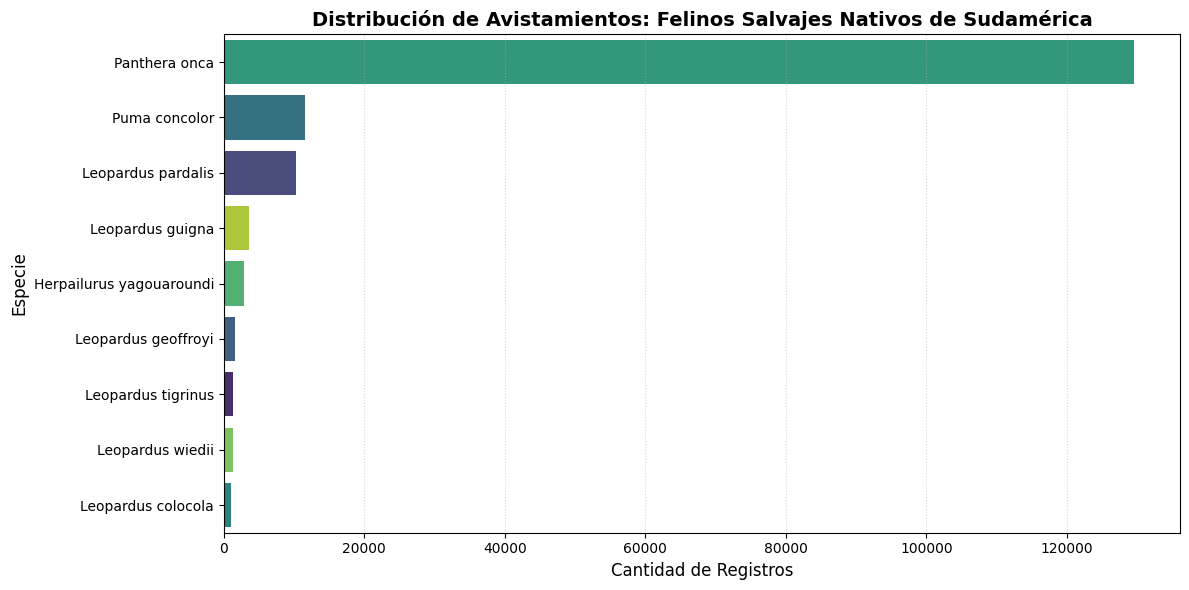

In [8]:
# Definimos la lista oficial de los felinos salvajes nativos más representativos de la región
felinos_nativos = [
    'Panthera onca', 'Puma concolor', 'Leopardus pardalis', 
    'Leopardus guigna', 'Herpailurus yagouaroundi', 'Leopardus geoffroyi', 
    'Leopardus tigrinus', 'Leopardus wiedii', 'Leopardus colocola'
]

# Filtramos el DataFrame temporalmente para la gráfica
df_nativos = df[df['species'].isin(felinos_nativos)]

# Graficamos con Seaborn 
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_nativos, 
    y='species', 
    order=felinos_nativos, 
    palette='viridis', 
    hue='species', 
    legend=False
)

plt.title('Distribución de Avistamientos: Felinos Salvajes Nativos de Sudamérica', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Registros', fontsize=12)
plt.ylabel('Especie', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


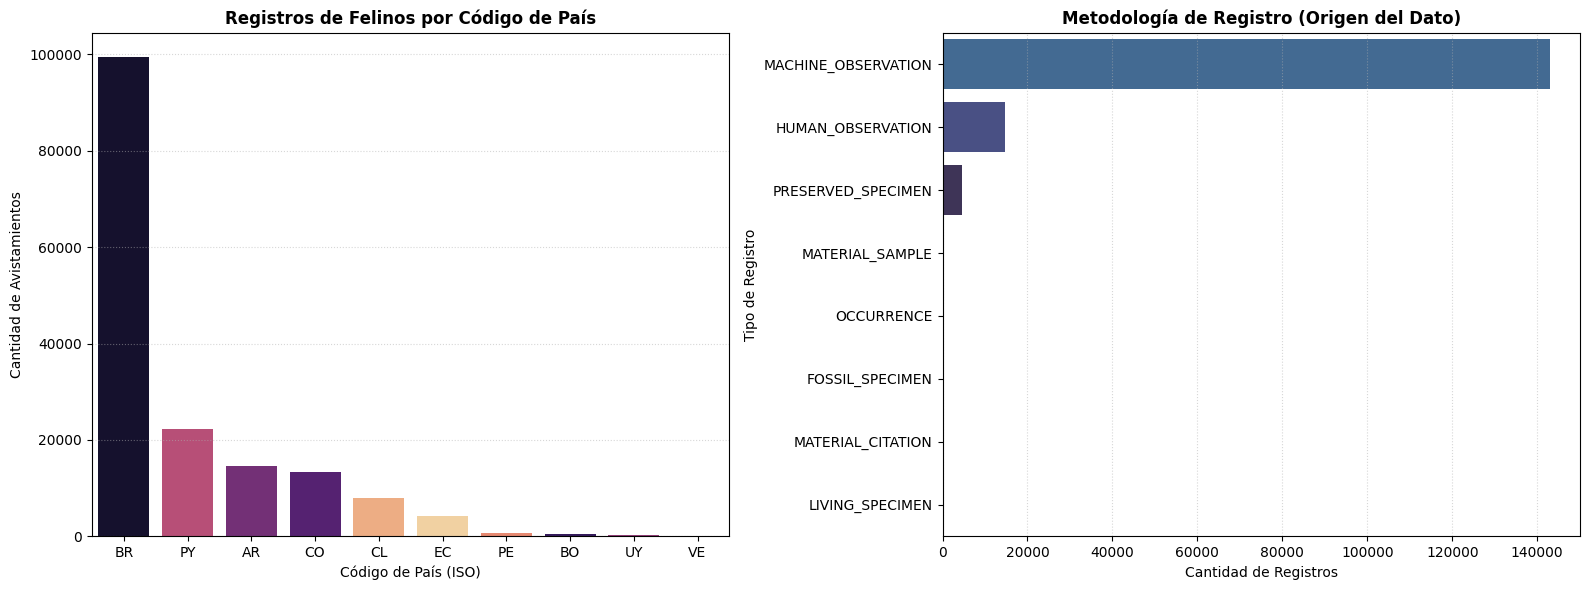

In [9]:
# Configurar la figura con dos gráficos en paralelo (Subplots)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico Izquierdo: Top de Países con más avistamientos de felinos
sns.countplot(
    data=df_nativos, 
    x='countryCode', 
    order=df_nativos['countryCode'].value_counts().index, 
    palette='magma', 
    hue='countryCode', 
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Registros de Felinos por Código de País', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Código de País (ISO)')
axes[0].set_ylabel('Cantidad de Avistamientos')
axes[0].grid(axis='y', linestyle=':', alpha=0.5)

# Gráfico Derecho: ¿Cómo se recolectaron los datos? (Metodología)
sns.countplot(
    data=df_nativos, 
    y='basisOfRecord', 
    order=df_nativos['basisOfRecord'].value_counts().index, 
    palette='mako', 
    hue='basisOfRecord', 
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Metodología de Registro (Origen del Dato)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cantidad de Registros')
axes[1].set_ylabel('Tipo de Registro')
axes[1].grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


### Análisis Geopolítico y Metodológico de los Avistamientos

Al evaluar el origen geográfico y operativo del dataset filtrado por especies nativas, extraemos conclusiones críticas sobre el sesgo de la investigación de felinos en Sudamérica:

*   **Monopolio Territorial de Brasil (BR):** El gráfico de la izquierda revela que **Brasil lidera abrumadoramente el dataset con cerca de 100,000 registros**, seguido a gran distancia por Paraguay (PY), Argentina (AR) y Colombia (CO). Países como Venezuela (VE) o Uruguay (UY) muestran barras casi imperceptibles. Esto confirma que el dataset está fuertemente influenciado por los esfuerzos de conservación e instituciones de monitoreo brasileñas (probablemente en biomas clave como el Amazonas, el Cerrado o el Pantanal).
*   **Dominio de la Tecnología Automatizada (MACHINE_OBSERVATION):** El gráfico metodológico de la derecha muestra que más del 80% de los datos provienen de observaciones mecánicas (cámaras trampa con sensores de movimiento o collares de telemetría). Las observaciones humanas directas (HUMAN_OBSERVATION) y las muestras de museos (PRESERVED_SPECIMEN) ocupan un lugar secundario. 
*   **Impacto para Machine Learning:** Que la gran mayoría de los datos sean `MACHINE_OBSERVATION` es una excelente noticia para nuestros futuros modelos de Clustering. Al ser registros automatizados por coordenadas automatizadas (GPS/sensores), el margen de error humano en la localización disminuye drásticamente en comparación con los reportes de avistamientos hechos a ojo por personas.


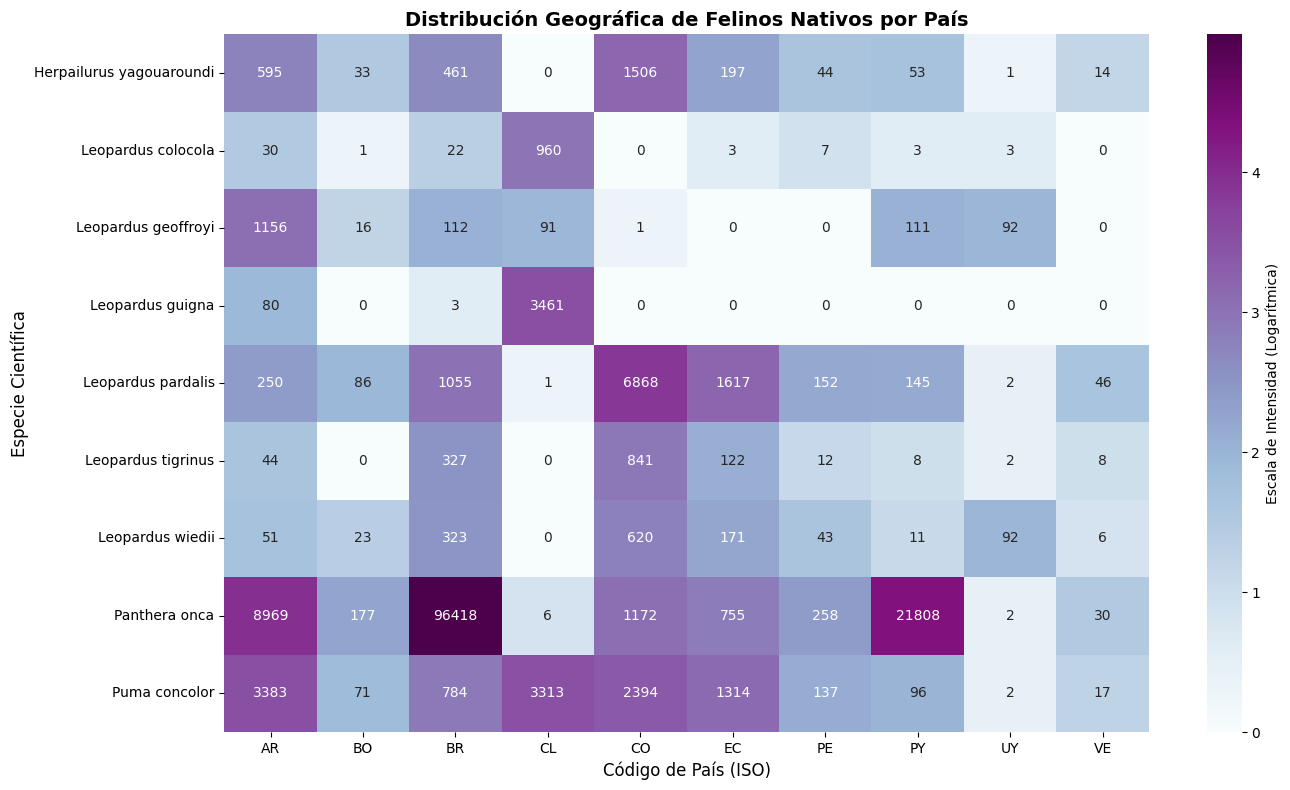

In [11]:
import numpy as np
import matplotlib.ticker as ticker

# Invertimos la tabla cruzada para cambiar la orientación (Especie en filas, País en columnas)
tabla_invertida = pd.crosstab(df_nativos['species'], df_nativos['countryCode'])

# Aplicamos una transformación logarítmica suave para equilibrar los colores
# Sumamos 1 para evitar errores matemáticos con los ceros log(0)
tabla_log = np.log10(tabla_invertida + 1)

plt.figure(figsize=(14, 8))

# Graficamos el mapa de calor con los ejes corregidos
sns.heatmap(
    tabla_log, 
    annot=tabla_invertida, # Mantendremos impresos los números reales originales
    fmt="d", 
    cmap="BuPu", 
    cbar_kws={'label': 'Escala de Intensidad (Logarítmica)'}
)

plt.title('Distribución Geográfica de Felinos Nativos por País', fontsize=14, fontweight='bold')
plt.xlabel('Código de País (ISO)', fontsize=12)
plt.ylabel('Especie Científica', fontsize=12)

plt.yticks(rotation=0) 
plt.tight_layout()
plt.show()


### Correlación Espacial entre Especies y Regiones Políticas

El análisis avanzado de la distribución geográfica mediante mapas de calor optimizados revela la segmentación biológica real de las especies dentro del continente:

*   **Especialización Endémica:** El gráfico demuestra con claridad que *Leopardus guigna* (Güiña) está estrictamente acotada a Chile (CL) y Argentina (AR), con cero registros en el resto del continente, respetando su nicho ecológico de bosques templados andino-patagónicos.
*   **Generalistas Regionales:** El puma (*Puma concolor*) y el ocelote (*Leopardus pardalis*) muestran una presencia distribuida a lo largo de casi todos los países de la muestra, confirmando su alta plasticidad y capacidad de adaptación a diferentes biomas (desde el altiplano hasta las llanuras tropicales).
*   **Focos de Monitoreo Crítico:** Identificamos que el grueso de la investigación de *Herpailurus yagouaroundi* (Yaguarundí) y *Leopardus tigrinus* se concentra de forma masiva en Colombia (CO) y Brasil (BR).
